In [7]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import basis, qeye, ptrace, sigmaz, sigmax, mesolve
from cmath import sqrt

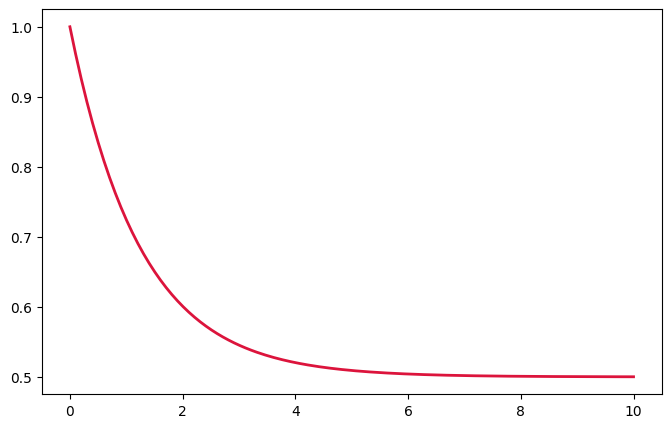

In [8]:
#Define the intial state(the pure state)
psi0 = (basis(2,0) + basis(2,1)).unit()  #makes a |+> state
rho0 = psi0 * psi0.dag()     #makes a density matrix from the pure state

#Define the Hamiltonian (the energy evolution operator)
omega = 1.0 * 2 * np.pi
H = 0.5 * omega * sigmaz()    #H = 1/2 * omega * sigma_z

#Define the collapse operators (Noise channels)
gamma = 0.2      #decoherence rate
c_ops = [sqrt(gamma) * sigmaz()]   #dephasing channel

#creating a timegrid
tlist = np.linspace(0, 10, 200)  #QuTip will calculate the state of the qubit at each of these timestamps

#Simulating the evolution
result = mesolve(H, rho0, tlist, c_ops=c_ops)   #gives the density matrix of the qubit at each timestamp in tlist

#Tracking purity
purities = [rho.purity() for rho in result.states]    #calculates the purity of the density matrix at each timestamp

#Plotting the results 
plt.figure(figsize = (8,5))
plt.plot(tlist, purities, label = 'Purity', color = 'crimson', lw = 2)